## Pranay's Contribution:

llm Prompts used:
- how to build a model similar to glide or other text to image models
- how it is different from ddpm model
- why caption data is important and how the model is going to know the relation
- can you help with my task with code and exaplain each and every step whats going on.
- how to calculate the FID and IS scores and how they will evaluate the model performance
- what can be done more?

In [ ]:
from google.colab import files
uploaded = files.upload()


Saving train_images.zip to train_images.zip


In [ ]:
from zipfile import ZipFile

# Unzip the train_images.zip file
with ZipFile('train_images.zip', 'r') as zip_ref:
    zip_ref.extractall('/content/train_images')


In [ ]:
import os

# List the content of the train_images folder to verify
train_image_dir = '/content/train_images'
classes = os.listdir(train_image_dir)
print(f"Classes found: {classes}")


Classes found: ['menu', 'outside', 'drink', 'inside', 'food']


In [ ]:
import os
import pandas as pd

# Load the CSV file into a DataFrame
df = pd.read_csv('/content/train_data.csv')

# Path to the train images folder
train_image_dir = '/content/train_images'

# List of all image files in the train images directory
image_files_in_dir = os.listdir(train_image_dir)

# Check if each image in the CSV file exists in the directory
missing_images = []
for photo_id in df['photo_id']:
    image_file_name = f"{photo_id}.jpg"  # Assuming the images are in .jpg format
    if image_file_name not in image_files_in_dir:
        missing_images.append(photo_id)

# Output the result
if missing_images:
    print(f"Missing images: {missing_images}")
else:
    print("All images in the CSV are present in the train images folder!")


Missing images: ['9Mx1UkeLQpOBDljydHdgBA', 'ZzMxyux7G_XNmweeFsXqUw', '7a7dMZSSk34yJOOjVPZZ4A', 'EjrZpX7t617uqeGpmGSAHg', 'Hp92EUdNUgfoaTI_a3Hgjw', 'dwtRuikkz1w88lLewhbqeA', '3K-uGZa1muqUvqSBPIQhNg', '4PwakZSoDCu1lCAMOhapCg', 'UBwmnNjsdfqdvVT2pj4VUQ', 'aZ0dFd5g-yQo4laaQWT_KQ', 'OYIsNuTgWuVBrb6UhanuQg', '2txJonF8EzlQEqNpmqIOnw', 'DwojSFDf9stCrmxvc6xLcQ', 'yerj-A6djWFcGGTC-lTLmA', 'x3mJuIEll5vHnD0EKJhgrw', 'Sw_iIM8iKqfOMQ_7DypDjA', 'mvQE1Mvit58KvB9qX2RTrw', '4bN0iJ7VK_bvBtVB0RtlWQ', 'yD9lk1Xv-F5PmXSwTNzWOA', '7ar4qXUuu6SPy63kUfFVog', 'I0DX2741f_ADy5jt-p-YEA', 'IA_rf2jwZRZwuav6f4VSaQ', 'B5FJzSIvEx4EfqgIivvrrQ', '8bIHhgCC7Qp50ivg7i97Qw', 'tV4qcsOCWgisUWFCWPlKsQ', 'VF-JVM5qBJ2J19CGBrnU3g', '_2wOUhyaeh5K5Y6y2WOCSA', 'j0sVFsQDDgklS0ap5t8-BQ', 'U-WqTWuFw83JCh2M8YGQCQ', '4VuLCK1irv6X1fzbY30krw', 'sjAozVC15hKMqi4PAmzFkA', 'E7oQYo4Jy2BTOuywbQbfbA', 'xc18zUARfazg2qqaoHqWcA', 'HTRvn944hIB6vT8zMJ7Qww', 'RWD9shq5qYLkRcEVymqKCw', '6nwEMPvd9_jQj14RrfwvkA', 'Ioj93rahL9j4z2CfBwWyUg', 'A6Wq-Y8ry9ZeOD_KkxSu

In [ ]:
# List of possible image extensions
image_extensions = ['.jpg', '.png']

# Check if each image in the CSV file exists in the directory
missing_images = []
for photo_id in df['photo_id']:
    found = False
    for ext in image_extensions:
        image_file_name = f"{photo_id}{ext}"
        if image_file_name in image_files_in_dir:
            found = True
            break
    if not found:
        missing_images.append(photo_id)

# Output the result
if missing_images:
    print(f"Missing images: {missing_images}")
else:
    print("All images in the CSV are present in the train images folder!")


Missing images: ['9Mx1UkeLQpOBDljydHdgBA', 'ZzMxyux7G_XNmweeFsXqUw', '7a7dMZSSk34yJOOjVPZZ4A', 'EjrZpX7t617uqeGpmGSAHg', 'Hp92EUdNUgfoaTI_a3Hgjw', 'dwtRuikkz1w88lLewhbqeA', '3K-uGZa1muqUvqSBPIQhNg', '4PwakZSoDCu1lCAMOhapCg', 'UBwmnNjsdfqdvVT2pj4VUQ', 'aZ0dFd5g-yQo4laaQWT_KQ', 'OYIsNuTgWuVBrb6UhanuQg', '2txJonF8EzlQEqNpmqIOnw', 'DwojSFDf9stCrmxvc6xLcQ', 'yerj-A6djWFcGGTC-lTLmA', 'x3mJuIEll5vHnD0EKJhgrw', 'Sw_iIM8iKqfOMQ_7DypDjA', 'mvQE1Mvit58KvB9qX2RTrw', '4bN0iJ7VK_bvBtVB0RtlWQ', 'yD9lk1Xv-F5PmXSwTNzWOA', '7ar4qXUuu6SPy63kUfFVog', 'I0DX2741f_ADy5jt-p-YEA', 'IA_rf2jwZRZwuav6f4VSaQ', 'B5FJzSIvEx4EfqgIivvrrQ', '8bIHhgCC7Qp50ivg7i97Qw', 'tV4qcsOCWgisUWFCWPlKsQ', 'VF-JVM5qBJ2J19CGBrnU3g', '_2wOUhyaeh5K5Y6y2WOCSA', 'j0sVFsQDDgklS0ap5t8-BQ', 'U-WqTWuFw83JCh2M8YGQCQ', '4VuLCK1irv6X1fzbY30krw', 'sjAozVC15hKMqi4PAmzFkA', 'E7oQYo4Jy2BTOuywbQbfbA', 'xc18zUARfazg2qqaoHqWcA', 'HTRvn944hIB6vT8zMJ7Qww', 'RWD9shq5qYLkRcEVymqKCw', '6nwEMPvd9_jQj14RrfwvkA', 'Ioj93rahL9j4z2CfBwWyUg', 'A6Wq-Y8ry9ZeOD_KkxSu

In [ ]:
import pandas as pd

# Load the CSV file
csv_path = "/content/train_data.csv"
df = pd.read_csv(csv_path)

# Display basic info
print("📊 CSV File Summary:\n")
print(f"Shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}\n")
print("First 5 rows:")
print(df.head(), "\n")

# If it has a label column, show unique classes
if 'label' in df.columns:
    print("Unique labels found in 'label' column:")
    print(df['label'].unique())
elif 'class' in df.columns:
    print("Unique labels found in 'class' column:")
    print(df['class'].unique())
elif 'category' in df.columns:
    print("Unique labels found in 'category' column:")
    print(df['category'].unique())


📊 CSV File Summary:

Shape: (3000, 4)
Columns: ['photo_id', 'business_id', 'caption', 'label']

First 5 rows:
                 photo_id             business_id  \
0  9Mx1UkeLQpOBDljydHdgBA  ww3YJXu5c18aGZXWmm00qg   
1  ZzMxyux7G_XNmweeFsXqUw  w2O0CQ_cIeje-5VM77SR0g   
2  7a7dMZSSk34yJOOjVPZZ4A  wBS-_MTeOaJKsfAy-Ts6pg   
3  EjrZpX7t617uqeGpmGSAHg  psAxJwaulyGN_9L-Zrkszg   
4  Hp92EUdNUgfoaTI_a3Hgjw  AglkyqtcY_NHlaZHYGJRRQ   

                                             caption label  
0                                        Salmon cake  food  
1                                      Queso Fundido  food  
2                                      Almost Reuben  food  
3  Orleáns sampler with fried green tomatoes inst...  food  
4  Dinner fro two! Fallaffel, hummos, baba and pi...  food   

Unique labels found in 'label' column:
['food' 'inside' 'outside' 'menu' 'drink']


In [ ]:
import os
import pandas as pd

# Load CSV
df = pd.read_csv('/content/train_data.csv')

# Root directory where images are stored by label
image_root_dir = '/content/train_images'

# Build a set of all actual image filenames across all label folders
actual_images = set()
for label in os.listdir(image_root_dir):
    label_path = os.path.join(image_root_dir, label)
    if os.path.isdir(label_path):
        for img_file in os.listdir(label_path):
            if img_file.endswith('.jpg'):
                actual_images.add(img_file)

# Get expected image filenames from photo_id column
df['expected_filename'] = df['photo_id'] + '.jpg'

# Compare
df['image_exists'] = df['expected_filename'].isin(actual_images)

# Summary
missing_images = df[~df['image_exists']]['expected_filename'].tolist()
print(f"Total expected: {len(df)}")
print(f"Found: {df['image_exists'].sum()}")
print(f"Missing: {len(missing_images)}")
print(f"Missing image files (first 10): {missing_images[:10]}")


Total expected: 3000
Found: 3000
Missing: 0
Missing image files (first 10): []


In [ ]:
import pandas as pd

# Load the CSV file
csv_path = "/content/train_data.csv"  # adjust if needed
df = pd.read_csv(csv_path)

# Display a few rows to confirm
print("Dataset Shape:", df.shape)
print(df.head())
print("\nUnique Labels:", df['label'].unique())


Dataset Shape: (3000, 4)
                 photo_id             business_id  \
0  9Mx1UkeLQpOBDljydHdgBA  ww3YJXu5c18aGZXWmm00qg   
1  ZzMxyux7G_XNmweeFsXqUw  w2O0CQ_cIeje-5VM77SR0g   
2  7a7dMZSSk34yJOOjVPZZ4A  wBS-_MTeOaJKsfAy-Ts6pg   
3  EjrZpX7t617uqeGpmGSAHg  psAxJwaulyGN_9L-Zrkszg   
4  Hp92EUdNUgfoaTI_a3Hgjw  AglkyqtcY_NHlaZHYGJRRQ   

                                             caption label  
0                                        Salmon cake  food  
1                                      Queso Fundido  food  
2                                      Almost Reuben  food  
3  Orleáns sampler with fried green tomatoes inst...  food  
4  Dinner fro two! Fallaffel, hummos, baba and pi...  food  

Unique Labels: ['food' 'inside' 'outside' 'menu' 'drink']


In [ ]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from transformers import CLIPTokenizer, CLIPTextModel
from PIL import Image
from torch.utils.data import Dataset, DataLoader
import pandas as pd


In [ ]:
# Load CSV file containing image paths and captions
df = pd.read_csv('/content/train_data.csv')

# Root directory where images are stored by label
image_root_dir = '/content/train_images'

# Dataset class to load images and captions
class ImageTextDataset(Dataset):
    def __init__(self, df, image_root_dir, tokenizer, transform=None):
        self.df = df
        self.image_root_dir = image_root_dir
        self.tokenizer = tokenizer
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        # Get the photo_id, caption, and label for this sample
        photo_id = self.df.iloc[idx]['photo_id']
        caption = self.df.iloc[idx]['caption']

        # Load image
        image_path = os.path.join(self.image_root_dir, photo_id + '.jpg')
        image = Image.open(image_path).convert("RGB")

        # Apply transformations if provided
        if self.transform:
            image = self.transform(image)

        # Tokenize the caption
        tokens = self.tokenizer(caption, padding='max_length', truncation=True, max_length=77, return_tensors="pt")

        return image, tokens


In [ ]:
class UNet(nn.Module):
    def __init__(self, in_channels, out_channels):
        super(UNet, self).__init__()

        # Convolutional layers for image processing
        self.conv1 = nn.Conv2d(in_channels, 64, kernel_size=3, padding=1)
        self.conv2 = nn.Conv2d(64, 128, kernel_size=3, padding=1)

        # Fully connected layers for text embeddings
        self.fc1 = nn.Linear(512, 1024)  # Flattened text embedding input
        self.fc2 = nn.Linear(1024, 128)  # Intermediate processing of text embeddings to match image channels

        # Adjust output layer to match flattened image size after convolution
        self.fc3 = nn.Linear(128 * 64 * 64, out_channels)  # Adjusted to match flattened size of the image

        # Activation function and pooling
        self.relu = nn.ReLU()
        self.maxpool = nn.MaxPool2d(2)

    def forward(self, x, skip):
        # Image processing through convolutional layers
        x = self.relu(self.conv1(x))
        x = self.maxpool(x)
        x = self.relu(self.conv2(x))

        # Process the text embeddings (skip)
        skip = skip.view(skip.size(0), -1)  # Flatten text embeddings to shape [batch_size, 512]
        skip = self.relu(self.fc1(skip))
        skip = self.relu(self.fc2(skip))  # Now, skip has shape [batch_size, 128]

        # Reshape skip (text embeddings) to match the spatial dimensions of x
        skip = skip.unsqueeze(2).unsqueeze(3)  # Add spatial dimensions [batch_size, 128, 1, 1]

        # Get the height and width of x for broadcasting
        H, W = x.size(2), x.size(3)

        # Broadcast the text embeddings to match the image size [batch_size, 128, H, W]
        skip = skip.expand(-1, 128, H, W)  # Match the height and width of the image tensor

        # Combine image and text embeddings (skip)
        x = x + skip  # Broadcasting happens here

        # Flatten the output tensor
        x = x.view(x.size(0), -1)  # Flatten to [batch_size, 128 * H * W]

        # Final output layer to produce the desired output channels
        x = self.fc3(x)

        return x

# Instantiate the UNet model
unet_model = UNet(in_channels=3, out_channels=3).to(device)

# Example of forward pass
# Assuming image data (images) and text embeddings (text_embeddings) are provided as inputs
# images shape: [batch_size, 3, 128, 128]
# text_embeddings shape: [batch_size, 512]

# Test with a dummy input to check the forward pass
dummy_images = torch.randn(8, 3, 128, 128).to(device)  # Batch of 8 images (RGB, 128x128)
dummy_text_embeddings = torch.randn(8, 512).to(device)  # Dummy text embeddings (batch size of 8)

# Forward pass
output = unet_model(dummy_images, dummy_text_embeddings)
print("Output shape:", output.shape)


Output shape: torch.Size([8, 3])


In [ ]:
import os
import pandas as pd
from torch.utils.data import Dataset, DataLoader, random_split
from PIL import Image
from torchvision import transforms
from transformers import CLIPTokenizer
import torch

# Example configuration (update these with your actual paths and values)
image_dir = '/content/train_images/'
caption_file = '/content/train_data.csv'
image_size = 128  # Set the image size
val_split = 0.2  # 20% for validation
batch_size = 8  # Batch size for training and validation

# Initialize the CLIP tokenizer
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")

# Data Preparation Class
class YelpCaptionedDataset(Dataset):
    def __init__(self, caption_csv, image_folder, transform, tokenizer):
        self.df = pd.read_csv(caption_csv)

        # Filter for specific labels
        self.df = self.df[self.df['label'].isin(['food', 'drink', 'menu', 'outside', 'inside'])]

        print("\nOriginal label distribution:")
        print(self.df['label'].value_counts())

        # No sampling, using all data
        # self.df = self.df.groupby('label').apply(
        #     lambda x: x.sample(n=min(max_samples_per_class, len(x)), random_state=42)
        # ).reset_index(drop=True)

        print("\nUsing all data without sampling:")
        print(self.df['label'].value_counts())

        # Setting image folder and transformation pipeline
        self.image_folder = image_folder
        self.transform = transform
        self.tokenizer = tokenizer

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        image_path = os.path.join(self.image_folder, row['label'], row['photo_id'] + ".jpg")

        # Load image and apply transformations
        image = Image.open(image_path).convert("RGB")
        image = self.transform(image)

        # Tokenize the caption using CLIP's tokenizer
        inputs = self.tokenizer(row['caption'], return_tensors="pt", padding="max_length", truncation=True, max_length=77)

        return {
            "pixel_values": image,
            "input_ids": inputs.input_ids.squeeze(0),  # Remove the extra batch dimension
            "caption": row['caption'],
            "label": row['label']
        }

# Transformation for image preprocessing
transform = transforms.Compose([
    transforms.Resize((image_size, image_size)),  # Resize to 128x128
    transforms.ToTensor(),  # Convert image to tensor
    transforms.Normalize([0.5, 0.5, 0.5], [0.5, 0.5, 0.5])  # Normalize image
])

# Instantiate the dataset
dataset = YelpCaptionedDataset(caption_csv=caption_file, image_folder=image_dir, transform=transform, tokenizer=tokenizer)

# Split dataset into train and validation sets
val_size = int(val_split * len(dataset))
train_size = len(dataset) - val_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

# Create DataLoader for train and validation sets
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=batch_size)

# Checking output from the DataLoader
for batch in train_loader:
    images = batch['pixel_values']
    input_ids = batch['input_ids']
    captions = batch['caption']
    labels = batch['label']
    print(images.size(), input_ids.size(), captions[0], labels[0])
    break  # Just check the first batch



Original label distribution:
label
food       600
inside     600
outside    600
menu       600
drink      600
Name: count, dtype: int64

Using all data without sampling:
label
food       600
inside     600
outside    600
menu       600
drink      600
Name: count, dtype: int64
torch.Size([8, 3, 128, 128]) torch.Size([8, 77]) Hefe Weissbier.  Beerlado! drink


In [ ]:
import torch
import torch.nn as nn
import math

class SinusoidalPosEmb(nn.Module):
    def __init__(self, dim):
        super(SinusoidalPosEmb, self).__init__()
        self.dim = dim

    def forward(self, t):
        device = t.device
        half_dim = self.dim // 2

        emb = math.log(10000) / (half_dim - 1)
        emb = torch.exp(torch.arange(half_dim, device=device) * -emb)

        emb = emb.unsqueeze(0)  # Shape becomes [1, half_dim]
        t = t.unsqueeze(-1)  # Shape becomes [batch_size, 1]

        emb = t * emb  # Broadcasting happens here, resulting in shape [batch_size, half_dim]

        # Concatenate sin and cos components to get the full embedding
        return torch.cat([emb.sin(), emb.cos()], dim=-1)

class SimpleUNet(nn.Module):
    def __init__(self, text_embed_dim, time_embed_dim=64):
        super(SimpleUNet, self).__init__()

        # Time and Text projections to a common dimension (e.g., 128)
        self.time_mlp = nn.Sequential(
    SinusoidalPosEmb(64),
    nn.Linear(64, 128),  # expects input with last dim=64
    nn.ReLU()
)

        self.text_proj = nn.Linear(text_embed_dim, 128)  # Project text embedding to 128 dimensions

        self.encoder = nn.Sequential(
            nn.Conv2d(131, 128, 3, padding=1),  # 3 channels + 128 conditioning channels
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )

        self.middle = nn.Sequential(
            nn.Conv2d(256, 256, 3, padding=1),
            nn.BatchNorm2d(256),
            nn.ReLU()
        )

        self.decoder = nn.Sequential(
            nn.Conv2d(256, 128, 3, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(),
            nn.Conv2d(128, 3, 3, padding=1)
        )

    def forward(self, x, t, text_emb):
        # Project the time step and text embeddings to the same dimension
        t_emb = self.time_mlp(t)
        txt_emb = self.text_proj(text_emb)

        # Ensure the dimensions of t_emb and txt_emb match before adding
        cond = t_emb + txt_emb  # Both are now [batch_size, 128]
        cond = cond[:, :, None, None].expand(-1, -1, x.shape[2], x.shape[3])  # Expand to match image size

        # Concatenate image and conditioning embeddings
        x = torch.cat([x, cond], dim=1)  # Now: 3 (RGB) + 128 = 131 channels
        h = self.encoder(x)
        h = self.middle(h)
        return self.decoder(h)

dummy_images = torch.randn(8, 3, 128, 128)          # Images
dummy_time = torch.randint(0, 1000, (8,)).float()   # Timesteps as scalars
dummy_text_emb = torch.randn(8, 512)                # Text embeddings

model = SimpleUNet(text_embed_dim=512)
output = model(dummy_images, dummy_time, dummy_text_emb)
print("Output shape:", output.shape)  # Expected: [8, 3, 128, 128]



Output shape: torch.Size([8, 3, 128, 128])


In [ ]:
timesteps = 1000
betas = torch.linspace(1e-4, 0.02, timesteps).to(device)
alphas = 1. - betas
alphas_cumprod = torch.cumprod(alphas, dim=0)


In [ ]:
@torch.no_grad()
def sample_ddpm(caption, model, tokenizer, text_encoder, steps=timesteps):
    model.eval()

    # Encode text
    inputs = tokenizer(caption, return_tensors="pt", padding="max_length", truncation=True, max_length=77).to(device)
    text_emb = text_encoder(**inputs).last_hidden_state.mean(dim=1)  # [1, 512]

    # Start from pure noise
    img = torch.randn(1, 3, image_size, image_size).to(device)

    for i in reversed(range(steps)):
        t = torch.full((1,), i, device=device).float()  # timestep as float
        noise_pred = model(img, t, text_emb)  # predicted noise

        alpha = alphas[i]
        alpha_hat = alphas_cumprod[i]
        beta = betas[i]

        if i > 0:
            noise = torch.randn_like(img)
        else:
            noise = torch.zeros_like(img)

        img = (1 / torch.sqrt(alpha)) * (img - ((1 - alpha) / torch.sqrt(1 - alpha_hat)) * noise_pred) + torch.sqrt(beta) * noise

    # Clamp values for visualization
    img = torch.clamp(img, -1., 1.)
    img = (img + 1) / 2  # scale to [0,1]
    return img


In [ ]:
# --- Forward Diffusion Function ---
def q_sample(x_start, t, noise):
    device = x_start.device
    sqrt_alpha_cumprod = torch.sqrt(alphas_cumprod.to(device)[t])[:, None, None, None]
    sqrt_one_minus_alpha = torch.sqrt(1. - alphas_cumprod.to(device)[t])[:, None, None, None]
    return sqrt_alpha_cumprod * x_start + sqrt_one_minus_alpha * noise


In [ ]:
import torch.nn.functional as F
from tqdm import tqdm

# --- Load text encoder and model ---
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").to(device)
model = SimpleUNet(text_embed_dim=512).to(device)
optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4)

num_epochs = 10
for epoch in range(num_epochs):
    model.train()
    train_loss = 0.0
    pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}")

    for batch in pbar:
        images = batch['pixel_values'].to(device)   # [B, 3, 128, 128]
        input_ids = batch['input_ids'].to(device)   # [B, 77]

        # --- 1. Sample random timesteps ---
        t = torch.randint(0, timesteps, (images.shape[0],), device=device).long()

        # --- 2. Forward diffusion: Add noise ---
        noise = torch.randn_like(images)
        x_noisy = q_sample(images, t, noise)  # ✅ use q_sample, not sample_ddpm

        # --- 3. Encode text ---
        with torch.no_grad():
            txt_emb = text_encoder(input_ids).last_hidden_state[:, 0, :]  # [B, 512]

        # --- 4. Predict noise ---
        noise_pred = model(x_noisy, t.float(), txt_emb)

        # --- 5. Compute loss ---
        loss = F.mse_loss(noise_pred, noise)

        # --- 6. Optimize ---
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        pbar.set_postfix(loss=loss.item())

    avg_loss = train_loss / len(train_loader)
    print(f"Epoch [{epoch+1}/{num_epochs}] - Avg Loss: {avg_loss:.4f}")


Epoch 1: 100%|██████████| 300/300 [01:15<00:00,  3.96it/s, loss=0.0725]


Epoch [1/10] - Avg Loss: 0.1389


Epoch 2: 100%|██████████| 300/300 [01:15<00:00,  3.97it/s, loss=0.0603]


Epoch [2/10] - Avg Loss: 0.0670


Epoch 3: 100%|██████████| 300/300 [01:15<00:00,  3.96it/s, loss=0.0242]


...

Epoch [8/10] - Avg Loss: 0.0443


Epoch 9: 100%|██████████| 300/300 [01:13<00:00,  4.10it/s, loss=0.0188]


Epoch [9/10] - Avg Loss: 0.0401


Epoch 10: 100%|██████████| 300/300 [01:13<00:00,  4.10it/s, loss=0.0271]

Epoch [10/10] - Avg Loss: 0.0385


In [ ]:
import zipfile
import os

# Path to the zip file and the directory to extract to
zip_path = '/content/test_images.zip'
extract_dir = '/content/test_images/'

# Unzip the file
with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_dir)

print(f"Test images unzipped to {extract_dir}")


Test images unzipped to /content/test_images/


In [ ]:
import pandas as pd

# Load the CSV containing the metadata
test_metadata_path = '/content/test_data.csv'
test_metadata = pd.read_csv(test_metadata_path)

# Check the first few rows of the CSV to understand its structure
print(test_metadata.head())


                 photo_id             business_id  \
0  q0g1woQf8gIzKrgiHZZc2w  0EPYrxeMLh2G63HLMIgRHg   
1  9VWvyQHFNLpgAwP9v3uqiA  SsHMgOW3TT48Z7jeV5beqQ   
2  BIWRBoclJFA-G6orCnHCkw  ImO3aF_axcKe5pwFf-jQeQ   
3  qXsgsvWV-ayHLQ0LnDe_Ow  -FM4CxOg4XXmX_Ebky_SiQ   
4  dlB2M2N58-rW271Apm193w  V9VLhHdSFpFi4yXFqVcVEA   

                                             caption label  
0                            Taco - Pulled Mojo Pork  food  
1                                      PRIME BRISKET  food  
2         Emmy Squared Gulch Nashville - Le Big Matt  food  
3  Really Creamy and plump!Highly Recommended the...  food  
4                      steak tartare w/ oyster aioli  food  


In [ ]:
import pandas as pd
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Load metadata from CSV
test_metadata_path = '/content/test_data.csv'
test_metadata = pd.read_csv(test_metadata_path)

# Inspect the data
print(test_metadata.head())

# Define the TestDataset class
class TestDataset(Dataset):
    def __init__(self, metadata, image_dir, transform=None):
        self.metadata = metadata
        self.image_dir = image_dir
        self.transform = transform

        # Define the possible classes (labels)
        self.classes = ['food', 'drink', 'menu', 'outside', 'inside']

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        # Get metadata for the sample
        row = self.metadata.iloc[idx]
        image_path = os.path.join(self.image_dir, row['label'], row['photo_id'] + ".jpg")

        # Load the image
        image = Image.open(image_path).convert("RGB")

        # Apply transformations (resize, normalize, etc.)
        if self.transform:
            image = self.transform(image)

        caption = row['caption']
        return {'pixel_values': image, 'caption': caption, 'label': row['label']}

# Define image transformations (resize to 299x299, normalize)
transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize to [-1, 1] range
])

# Create the test dataset
test_dataset = TestDataset(metadata=test_metadata, image_dir='/content/test_images/', transform=transform)

# Create DataLoader for batch processing
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)


                 photo_id             business_id  \
0  q0g1woQf8gIzKrgiHZZc2w  0EPYrxeMLh2G63HLMIgRHg   
1  9VWvyQHFNLpgAwP9v3uqiA  SsHMgOW3TT48Z7jeV5beqQ   
2  BIWRBoclJFA-G6orCnHCkw  ImO3aF_axcKe5pwFf-jQeQ   
3  qXsgsvWV-ayHLQ0LnDe_Ow  -FM4CxOg4XXmX_Ebky_SiQ   
4  dlB2M2N58-rW271Apm193w  V9VLhHdSFpFi4yXFqVcVEA   

                                             caption label  
0                            Taco - Pulled Mojo Pork  food  
1                                      PRIME BRISKET  food  
2         Emmy Squared Gulch Nashville - Le Big Matt  food  
3  Really Creamy and plump!Highly Recommended the...  food  
4                      steak tartare w/ oyster aioli  food  


In [ ]:
import pandas as pd
import os
from PIL import Image
import torch
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms

# Load the metadata from CSV
test_metadata_path = '/content/test_data.csv'
test_metadata = pd.read_csv(test_metadata_path)

# Check the metadata structure
print(test_metadata.head())

# Define the TestDataset class
class TestDataset(Dataset):
    def __init__(self, metadata, image_dir, transform=None):
        self.metadata = metadata
        self.image_dir = image_dir
        self.transform = transform

        # Define the possible classes (labels)
        self.classes = ['food', 'drink', 'menu', 'outside', 'inside']

    def __len__(self):
        return len(self.metadata)

    def __getitem__(self, idx):
        # Get metadata for the sample
        row = self.metadata.iloc[idx]
        image_path = os.path.join(self.image_dir, row['label'], row['photo_id'] + ".jpg")

        # Load the image
        image = Image.open(image_path).convert("RGB")

        # Apply transformations (resize, normalize, etc.)
        if self.transform:
            image = self.transform(image)

        caption = row['caption']
        return {'pixel_values': image, 'caption': caption, 'label': row['label']}

# Define image transformations (resize to 299x299, normalize)
transform = transforms.Compose([
    transforms.Resize((299, 299)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5, 0.5, 0.5], std=[0.5, 0.5, 0.5])  # Normalize to [-1, 1] range
])

# Create the test dataset
test_dataset = TestDataset(metadata=test_metadata, image_dir='/content/test_images/', transform=transform)

# Create DataLoader for batch processing
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# Check the length of the dataset and preview a batch
print(f"Test dataset size: {len(test_dataset)}")


                 photo_id             business_id  \
0  q0g1woQf8gIzKrgiHZZc2w  0EPYrxeMLh2G63HLMIgRHg   
1  9VWvyQHFNLpgAwP9v3uqiA  SsHMgOW3TT48Z7jeV5beqQ   
2  BIWRBoclJFA-G6orCnHCkw  ImO3aF_axcKe5pwFf-jQeQ   
3  qXsgsvWV-ayHLQ0LnDe_Ow  -FM4CxOg4XXmX_Ebky_SiQ   
4  dlB2M2N58-rW271Apm193w  V9VLhHdSFpFi4yXFqVcVEA   

                                             caption label  
0                            Taco - Pulled Mojo Pork  food  
1                                      PRIME BRISKET  food  
2         Emmy Squared Gulch Nashville - Le Big Matt  food  
3  Really Creamy and plump!Highly Recommended the...  food  
4                      steak tartare w/ oyster aioli  food  
Test dataset size: 1000


In [ ]:
from transformers import CLIPTextModel, CLIPTokenizer

# Load the CLIP model and tokenizer
tokenizer = CLIPTokenizer.from_pretrained("openai/clip-vit-base-patch32")
text_encoder = CLIPTextModel.from_pretrained("openai/clip-vit-base-patch32").to(device)


In [ ]:
# Define device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Reinitialize the model
model = SimpleUNet(text_embed_dim=512).to(device)

# Load your trained weights
model_path = '/content/trained_model.pth'   # <-- put your correct .pth file path
model.load_state_dict(torch.load(model_path, map_location=device))

# Set model to evaluation
model.eval()

print("✅ Model loaded successfully from", model_path)


✅ Model loaded successfully from /content/trained_model.pth



🔹 Generating and evaluating images on test set...


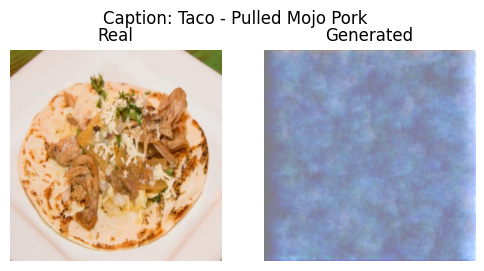

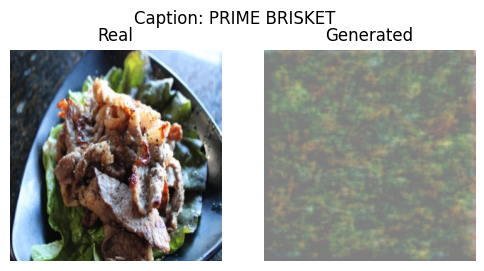

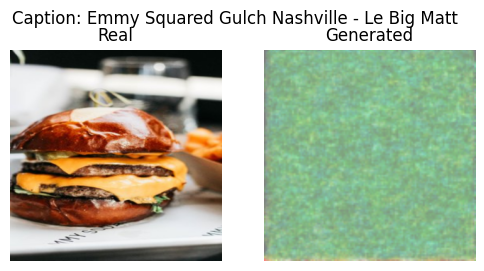

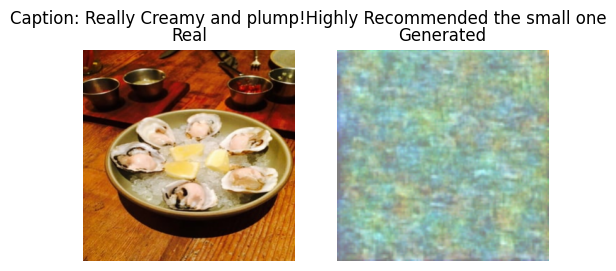

Creating feature extractor "inception-v3-compat" with features ['2048', 'logits_unbiased']
Downloading: "https://github.com/toshas/torch-fidelity/releases/download/v0.2.0/weights-inception-2015-12-05-6726825d.pth" to /root/.cache/torch/hub/checkpoints/weights-inception-2015-12-05-6726825d.pth
100%|██████████| 91.2M/91.2M [00:01<00:00, 66.1MB/s]
Extracting features from input1


ValueError: Input descriptor "input" field can be either an instance of Dataset, GenerativeModelBase class, or a string, such as a path to a name of a registered dataset (cifar10-train, cifar10-val, stl10-train, stl10-test, stl10-unlabeled), a directory with file samples, or a path to an ONNX or PTH (JIT) module

In [ ]:
import torch
import torchvision.transforms.functional as TF
import matplotlib.pyplot as plt
from tqdm import tqdm

# Ensure model is in eval mode
model.eval()

real_images = []
fake_images = []

print("\n🔹 Generating and evaluating images on test set...")

for i in range(min(50, len(test_dataset))):   # limit to 50 samples for speed
    data = test_dataset[i]
    real = data['pixel_values'].to(device)
    caption = data['caption']

    # Append real image for FID later
    real_images.append(TF.resize(real.cpu(), [299, 299]))

    # Generate fake image
    fake = sample_ddpm(caption, model, tokenizer, text_encoder)[0].cpu()
    fake_resized = TF.resize(fake, [299, 299])
    fake_images.append(fake_resized)

    # Show first 4 real vs generated images
    if i < 4:
        gen_img = fake_resized.permute(1, 2, 0).detach().numpy()
        real_img = real.cpu().permute(1, 2, 0).detach().numpy()

        fig, axs = plt.subplots(1, 2, figsize=(6, 3))
        axs[0].imshow((real_img + 1) / 2)
        axs[0].set_title("Real")
        axs[0].axis("off")
        axs[1].imshow((gen_img + 1) / 2)
        axs[1].set_title("Generated")
        axs[1].axis("off")
        plt.suptitle(f"Caption: {caption}")
        plt.show()

# Stack and normalize images
real_images = torch.stack(real_images)
fake_images = torch.stack(fake_images)

real_images = ((real_images + 1) / 2).clamp(0, 1)
fake_images = ((fake_images + 1) / 2).clamp(0, 1)

# ✅ Compute FID & Inception Score using torch_fidelity
from torch_fidelity import calculate_metrics

metrics = calculate_metrics(
    input1=fake_images,   # generated images
    input2=real_images,   # real images
    cuda=True,
    isc=True,
    fid=True
)

print("\n✅ Final Evaluation Metrics:")
print(f"FID Score: {metrics['frechet_inception_distance']:.4f}")
print(f"Inception Score: {metrics['inception_score_mean']:.4f} ± {metrics['inception_score_std']:.4f}")


In [ ]:
import os
from torchvision.utils import save_image
from torch_fidelity import calculate_metrics

# Create temp folders
os.makedirs("generated_images", exist_ok=True)
os.makedirs("real_images", exist_ok=True)

# Save fake images
for i, img in enumerate(fake_images):
    save_image(img, f"generated_images/{i}.png")

# Save real images
for i, img in enumerate(real_images):
    save_image(img, f"real_images/{i}.png")

# ✅ Compute both FID and Inception Score
metrics = calculate_metrics(
    input1="generated_images",   # Path to generated images
    input2="real_images",        # Path to real images
    cuda=True,
    isc=True,                    # Enables Inception Score
    fid=True                     # Enables FID
)

print("\nResults:")
print(f"FID: {metrics['frechet_inception_distance']}")
print(f"Inception Score: {metrics['inception_score_mean']} ± {metrics['inception_score_std']}")


Creating feature extractor "inception-v3-compat" with features ['2048', 'logits_unbiased']
Extracting features from input1
Looking for samples non-recursivelty in "generated_images" with extensions png,jpg,jpeg
Found 50 samples
Processing samples
Extracting features from input2
Looking for samples non-recursivelty in "real_images" with extensions png,jpg,jpeg
Found 50 samples
Processing samples
Inception Score: 1.7309683344137627 ± 0.21937887268319456



Results:
FID: 387.55439041982135
Inception Score: 1.7309683344137627 ± 0.21937887268319456


Frechet Inception Distance: 387.55439041982135
